# In-Class Activity (July 16, 2026)

In [1]:
library(tidyverse)
library(moderndive)

── Attaching core tidyverse packages ─────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
wage_data <- read.table("data/wage.txt", header=TRUE)
head(wage_data)

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,8,0,1,21,0,5.10,35,2,6,1,1
2,9,0,1,42,0,4.95,57,3,6,1,1
3,12,0,0,1,0,6.67,19,3,6,1,0
4,12,0,0,4,0,4.00,22,3,6,0,0
5,12,0,0,17,0,7.50,35,3,6,0,1
6,13,0,0,9,1,13.07,28,3,6,0,0


### Part A

In [3]:
wage_model <- lm(wage ~ education*sex, data = wage_data)
get_regression_table(wage_model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,1.105,1.314,0.841,0.401,-1.476,3.685
education,0.683,0.099,6.918,0.000,0.489,0.877
sex,-4.370,2.085,-2.096,0.037,-8.466,-0.274
education:sex,0.173,0.157,1.098,0.273,-0.136,0.481


The relationship between wage and education **does not** depend on sex when we consider a 0.05 confidence level. The reason for this is that the p-value for the `education:sex` coefficient is `0.273` which is substantially greater than 0.05 indicating that there is no statistically significant relationship between the interaction term and the response variable wage. When we perform the hypothesis test, we assume that beta_3 is 0 and given the large p-value, we fail to reject the null hypothesis.

In either case, the interpretation of the parameter beta_1 parameter does not stay the same. The beta_1 parameter is the slope for only the baseline reference category so when the interaction parameter exhibits statistical significance, the relationship between education and wage depends on sex.

### Part B

In [4]:
wage_model <- lm(wage ~ education*factor(occupation), data = wage_data)
get_regression_table(wage_model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,-5.665,4.165,-1.360,0.174,-13.847,2.516
education,1.260,0.283,4.459,0.000,0.705,1.815
factor(occupation): 2,3.793,7.210,0.526,0.599,-10.371,17.957
factor(occupation): 3,12.680,5.471,2.318,0.021,1.932,23.429
factor(occupation): 4,9.483,4.843,1.958,0.051,-0.031,18.997
factor(occupation): 5,5.360,5.377,0.997,0.319,-5.204,15.923
factor(occupation): 6,8.907,4.614,1.931,0.054,-0.157,17.970
education:factor(occupation)2,-0.543,0.525,-1.035,0.301,-1.574,0.487
education:factor(occupation)3,-1.228,0.392,-3.132,0.002,-1.999,-0.458


In [5]:
anova(wage_model)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
education,1,2053.2902,2053.29016,100.722018,8.619789e-22
factor(occupation),5,1100.7387,220.14774,10.799119,6.741435e-10
education:factor(occupation),5,281.3277,56.26554,2.760048,1.791979e-02
Residuals,522,10641.3422,20.38571,NA,NA


The relationship between wage and education may depend on occupation. We can perform a hypothesis test to determine this by first claiming beta_3 = 0 as the null hypothesis. We then reject the null hypothesis at a 0.05 significance level since some of the occupations have p-values less than 0.05. Since we fail to reject the null hypothesis this means that the relationship between wage and education may depend on occupation.

### Part C

In [6]:
wage_model <- lm(wage ~ education+factor(occupation)+sex, data = wage_data)
get_regression_table(wage_model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,6.342,1.535,4.131,0.000,3.326,9.358
education,0.484,0.095,5.096,0.000,0.298,0.671
factor(occupation): 2,-4.327,0.954,-4.535,0.000,-6.201,-2.453
factor(occupation): 3,-3.749,0.788,-4.758,0.000,-5.297,-2.201
factor(occupation): 4,-4.341,0.831,-5.226,0.000,-5.973,-2.709
factor(occupation): 5,-1.060,0.755,-1.405,0.161,-2.543,0.422
factor(occupation): 6,-3.114,0.770,-4.043,0.000,-4.626,-1.601
sex,-1.833,0.430,-4.258,0.000,-2.679,-0.987


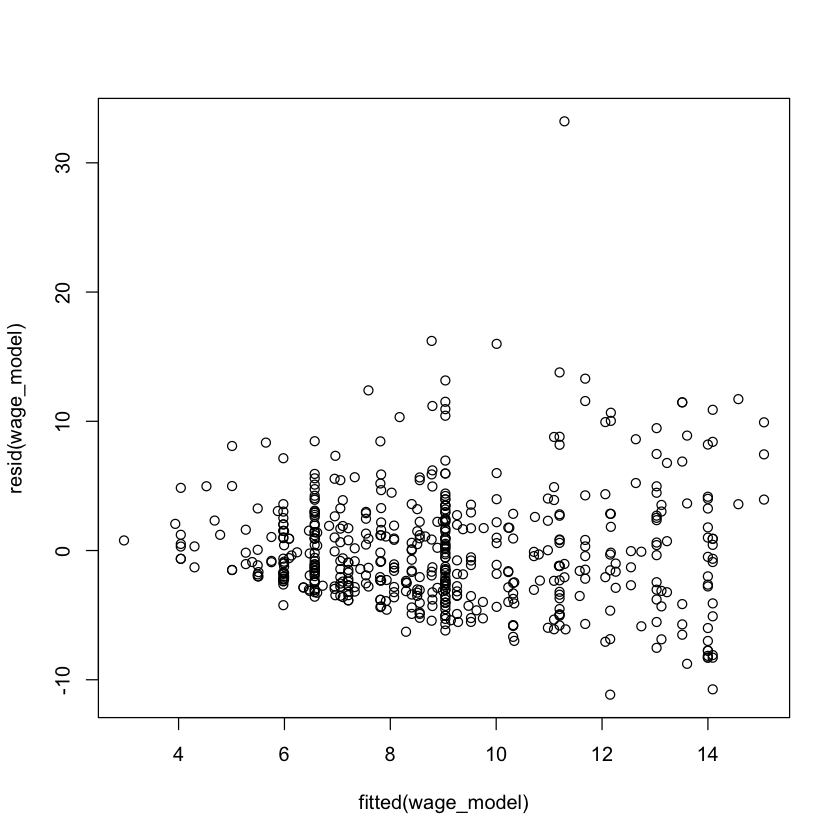

In [7]:
plot(fitted(wage_model), resid(wage_model))

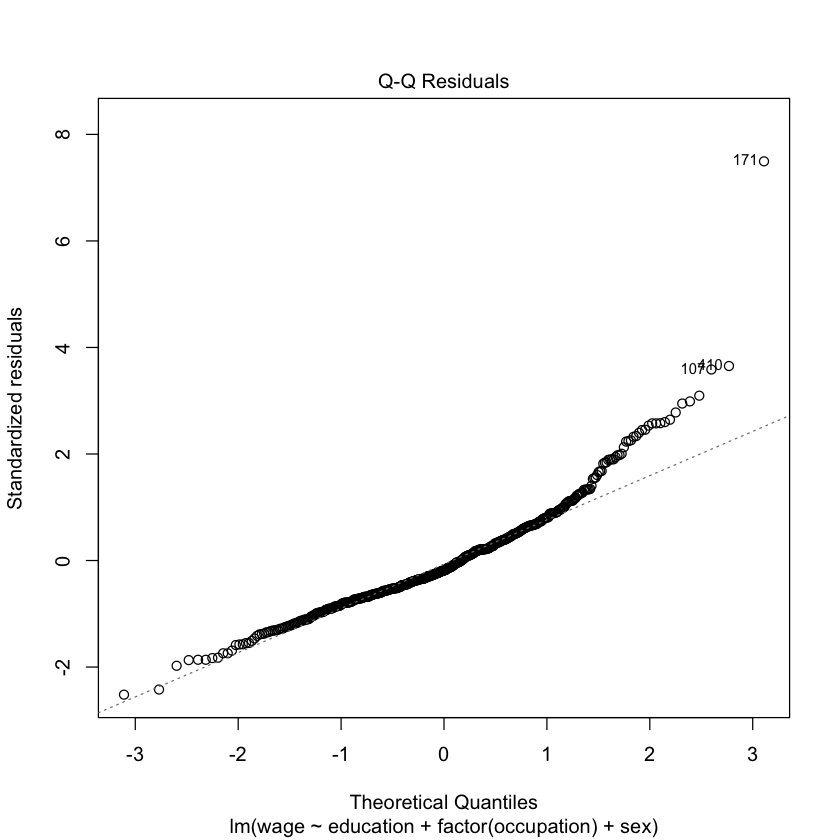

In [8]:
plot(wage_model, 2)

Based on the residual plot, we can see that the model does not fit the data very well since the residual values deviate more from 0 as the fitted model values increase. Ideally, the residual values should retain more consistent variance as the fitted values increase. This could be an indication that we should try some sort of transformation to correct the heteroscedasticity.

Based on the QQ plot, we can see that the standardized residuals increase as the theoretical quantiles increase which results in the points deviating from the reference line. Given this information, we can infer that the conditional distribution of the errors is may not be normal.

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,1.729,0.157,10.983,0.000,1.419,2.038
education,0.049,0.010,5.035,0.000,0.030,0.068
factor(occupation): 2,-0.393,0.098,-4.022,0.000,-0.586,-0.201
factor(occupation): 3,-0.263,0.081,-3.260,0.001,-0.422,-0.105
factor(occupation): 4,-0.420,0.085,-4.937,0.000,-0.588,-0.253
factor(occupation): 5,-0.015,0.077,-0.188,0.851,-0.167,0.137
factor(occupation): 6,-0.233,0.079,-2.957,0.003,-0.388,-0.078
sex,-0.209,0.044,-4.728,0.000,-0.295,-0.122


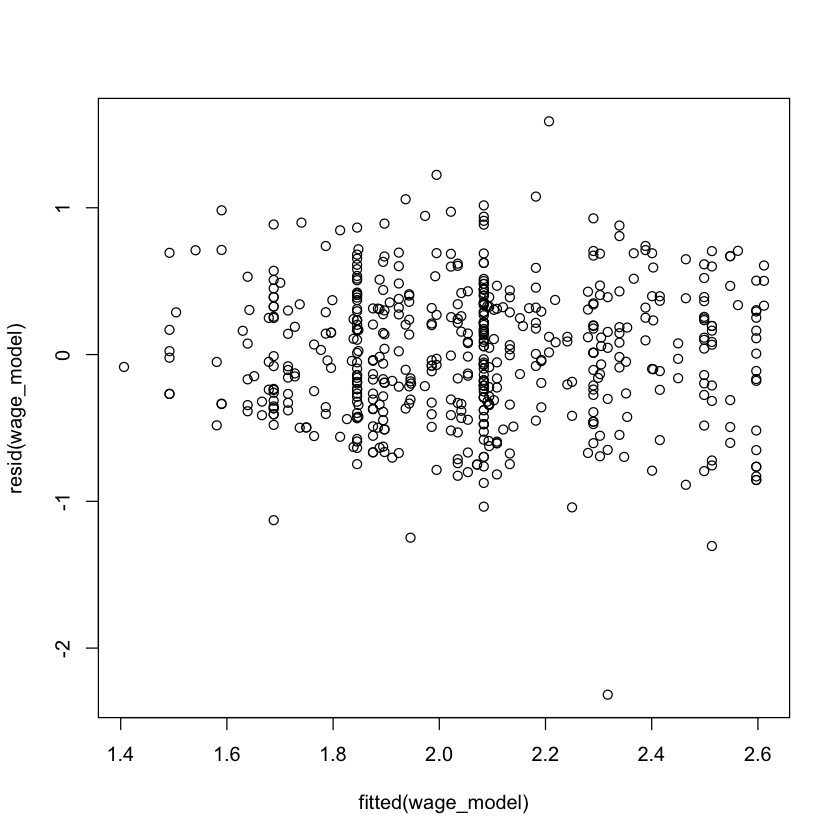

In [9]:
wage_model <- lm(log(wage) ~ education+factor(occupation)+sex, data = wage_data)
get_regression_table(wage_model)
plot(fitted(wage_model), resid(wage_model))

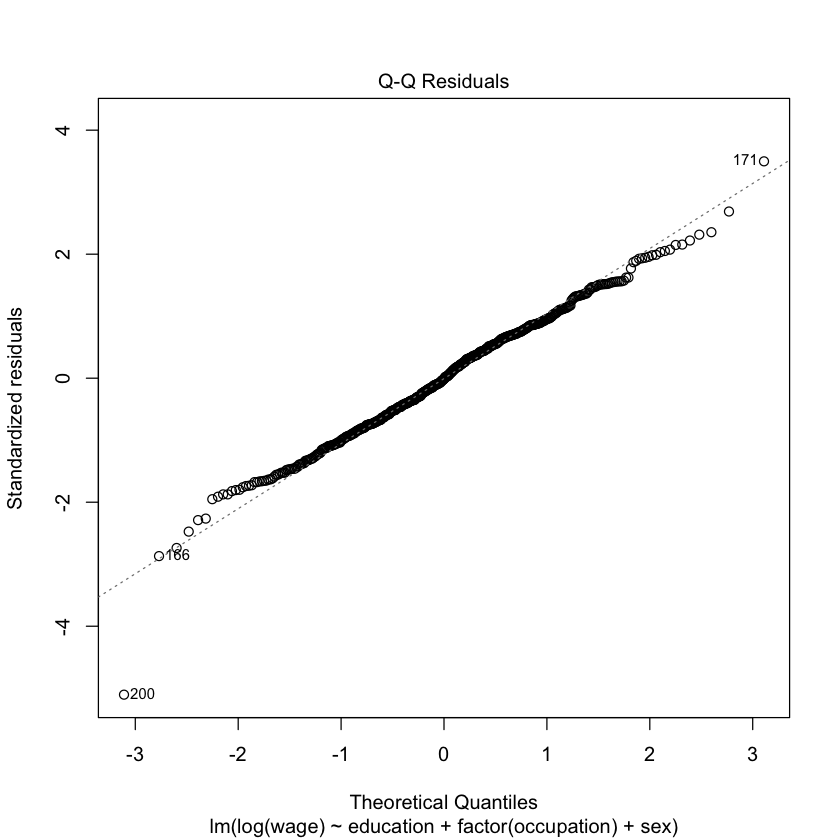

In [10]:
plot(wage_model, 2)

After transforming wage by taking log(y) when fitting the model, we can see more consistent variance in the residual plot, and a more normal distribution according to the QQ plot. Given this change to the model, the additive model now fits the data more effectively.